# Regularization Ablation Study: Baseline (Full EMNIST)
## No Regularization - Establishing the Generalization Gap

In [ ]:
!pip install torch torchvision matplotlib numpy -q


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

torch.manual_seed(42)
np.random.seed(42)


Device: cpu


In [ ]:
# MASTER CONFIG - Change regularization parameters here
MASTER_CONFIG = {
    'learning_rate': 0.01,
    'optimizer': 'SGD',
    'max_epochs': 20,
    'batch_size': 128,
    'num_classes': 47,
    'input_size': 784,
    'use_dropout': False,       # Toggle dropout regularization
    'use_batchnorm': False,     # Toggle batch normalization
    'seed': 42
}

print('\n' + '='*70)
print('MASTER CONFIG')
print('='*70)
for key, value in MASTER_CONFIG.items():
    print(f'{key:20s}: {value}')
print('='*70)



MASTER CONFIG
learning_rate       : 0.01
optimizer           : SGD
max_epochs          : 20
batch_size          : 128
num_classes         : 47
input_size          : 784
use_dropout         : False
use_batchnorm       : False
seed                : 42


In [ ]:
import ssl
import urllib.request

ssl._create_default_https_context = ssl._create_unverified_context

def load_emnist_full(batch_size=128):
    """Load EMNIST Balanced dataset with 80-20 train-val split."""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.1307,),
            std=(0.3081,)
        )
    ])
    
    print('Loading EMNIST Balanced...')
    
    train_dataset = datasets.EMNIST(
        root='./data',
        split='balanced',
        train=True,
        download=True,
        transform=transform
    )
    
    test_dataset = datasets.EMNIST(
        root='./data',
        split='balanced',
        train=False,
        download=True,
        transform=transform
    )
    
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_split, val_split = torch.utils.data.random_split(
        train_dataset,
        [train_size, val_size]
    )
    
    train_loader = DataLoader(train_split, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_split, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    print(f'Train: {len(train_split)} | Val: {len(val_split)} | Test: {len(test_dataset)}')
    
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = load_emnist_full(
    batch_size=MASTER_CONFIG['batch_size']
)


Loading EMNIST Balanced (Full Dataset)...


100.0%


Train: 90240 | Val: 22560 | Test: 18800


In [ ]:
# Network architecture for regularization ablation studies
class AblationMLP(nn.Module):
    """
    Multi-layer perceptron for regularization experiments.
    
    Toggle regularization here:
    - use_dropout: Enable/disable dropout layers
    - use_batchnorm: Enable/disable batch normalization
    """
    
    def __init__(self, use_dropout=False, use_batchnorm=False, dropout_p=0.5):
        super(AblationMLP, self).__init__()
        
        self.use_dropout = use_dropout
        self.use_batchnorm = use_batchnorm
        
        self.fc1 = nn.Linear(784, 512)
        self.bn1 = nn.BatchNorm1d(512) if use_batchnorm else None
        self.dropout1 = nn.Dropout(dropout_p) if use_dropout else None
        
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256) if use_batchnorm else None
        self.dropout2 = nn.Dropout(dropout_p) if use_dropout else None
        
        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128) if use_batchnorm else None
        self.dropout3 = nn.Dropout(dropout_p) if use_dropout else None
        
        self.fc4 = nn.Linear(128, 47)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        
        x = self.fc1(x)
        if self.bn1 is not None:
            x = self.bn1(x)
        x = self.relu(x)
        if self.dropout1 is not None:
            x = self.dropout1(x)
        
        x = self.fc2(x)
        if self.bn2 is not None:
            x = self.bn2(x)
        x = self.relu(x)
        if self.dropout2 is not None:
            x = self.dropout2(x)
        
        x = self.fc3(x)
        if self.bn3 is not None:
            x = self.bn3(x)
        x = self.relu(x)
        if self.dropout3 is not None:
            x = self.dropout3(x)
        
        x = self.fc4(x)
        return x

model = AblationMLP(
    use_dropout=MASTER_CONFIG['use_dropout'],
    use_batchnorm=MASTER_CONFIG['use_batchnorm']
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f'\nModel Parameters: {num_params:,}')
print(f'Use Dropout: {MASTER_CONFIG["use_dropout"]}')
print(f'Use BatchNorm: {MASTER_CONFIG["use_batchnorm"]}')



Model Parameters: 572,207
Use Dropout: False
Use BatchNorm: False


In [ ]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_loss = total_loss / len(val_loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=MASTER_CONFIG['learning_rate'])

print('Training setup complete')


Training setup complete


In [ ]:
print('\n' + '='*70)
print('TRAINING: BASELINE (NO REGULARIZATION)')
print('='*70)
print(f'Epochs: {MASTER_CONFIG["max_epochs"]} | LR: {MASTER_CONFIG["learning_rate"]}')
print('\nEpoch | Train Loss | Train Acc | Val Loss | Val Acc')
print('-'*60)

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

for epoch in range(MASTER_CONFIG['max_epochs']):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'{epoch+1:5d} | {train_loss:10.4f} | {train_acc:9.2f} | {val_loss:8.4f} | {val_acc:7.2f}')

print('\n✓ Training complete!')



TRAINING: BASELINE (FULL EMNIST, NO REGULARIZATION)
Epochs: 20 | LR: 0.01 | Optimizer: SGD

Epoch | Train Loss | Train Acc | Val Loss | Val Acc
------------------------------------------------------------
    1 |     3.7396 |     12.26 |   3.4227 |   24.28
    5 |     1.1105 |     67.67 |   1.0627 |   69.31
   10 |     0.7377 |     77.54 |   0.7482 |   77.49
   15 |     0.5788 |     81.65 |   0.6257 |   80.53
   20 |     0.4905 |     84.01 |   0.5581 |   82.14

✓ Training complete!


In [ ]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print('\n' + '='*70)
print('BASELINE RESULTS')
print('='*70)
print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.2f}%')
print(f'\nGeneralization Gap (Train vs Val at last epoch):')
print(f'  Train Accuracy: {history["train_acc"][-1]:.2f}%')
print(f'  Val Accuracy:   {history["val_acc"][-1]:.2f}%')
print(f'  Gap:            {history["train_acc"][-1] - history["val_acc"][-1]:.2f}%')
print('='*70)



BASELINE RESULTS
Test Loss:     0.5774
Test Accuracy: 81.67%

Generalization Gap (Train vs Val at last epoch):
  Train Accuracy: 84.01%
  Val Accuracy:   82.14%
  Gap:            1.87%


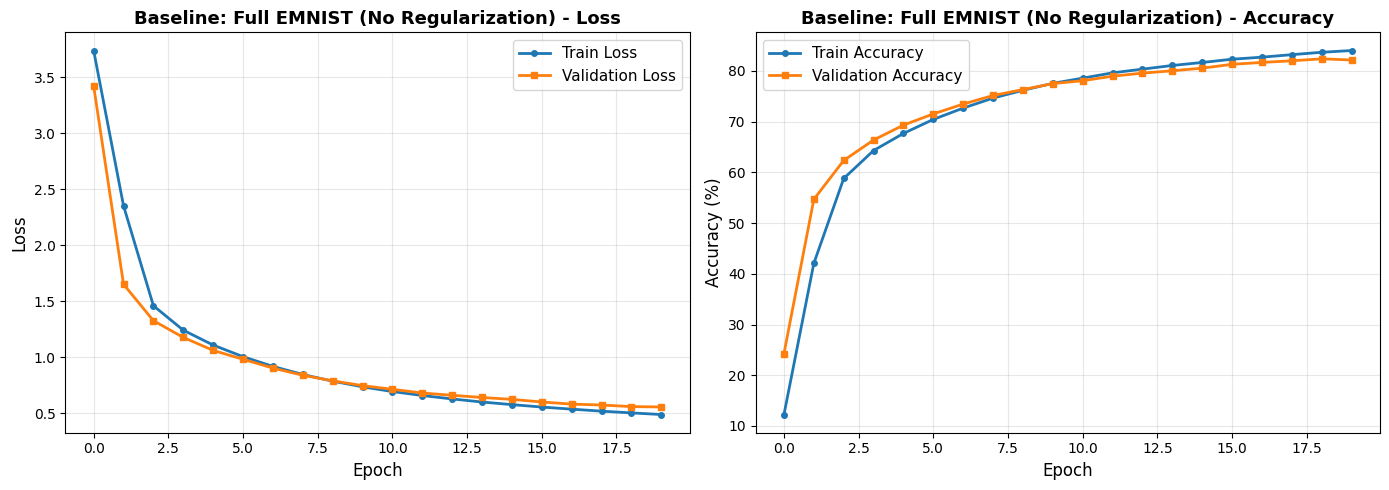


✓ Visualization complete


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss', marker='o', markersize=4, linewidth=2)
ax1.plot(history['val_loss'], label='Validation Loss', marker='s', markersize=4, linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Baseline: No Regularization - Loss', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train Accuracy', marker='o', markersize=4, linewidth=2)
ax2.plot(history['val_acc'], label='Validation Accuracy', marker='s', markersize=4, linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Baseline: No Regularization - Accuracy', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\n✓ Visualization complete')
